Exercise 1: Time Series Decomposition (Car Retail Dataset)

Abstract: Retail sales data collected over time often exhibits patterns such as long-term trends, seasonal variations, and random fluctuations, making it difficult to directly interpret the underlying behavior. Identifying and separating these components is essential for accurate analysis and forecasting. However, extracting these patterns from raw data can be challenging due to their overlapping nature. Therefore, there is a need for techniques that can decompose time series data into its fundamental components. Apply time series decomposition methods on the car retail dataset to separate it into trend, seasonal, and residual components, and analyze the patterns present in the data.

In [25]:
import numpy as np
import pandas as pd
%matplotlib inline

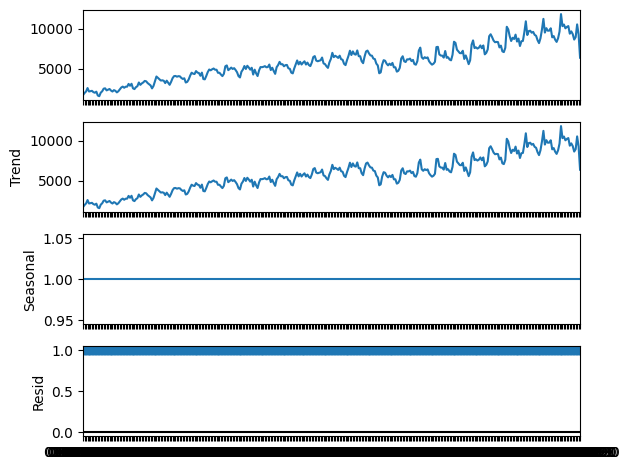

In [26]:
from matplotlib import pyplot
from statsmodels.tsa.seasonal import seasonal_decompose
series_2 = pd.read_csv('/content/retail.csv', header=0, index_col=0)
result = seasonal_decompose(series_2, model='multiplicative',period=1)
result.plot()
pyplot.show()

Exercise 2: Exponential Smoothing

Abstract: In many real-world scenarios, demand data collected over time may exhibit fluctuations due to random variations, making it difficult to identify the underlying pattern. Traditional methods like moving averages assign equal weights to past observations, which may not adequately reflect recent changes. Therefore, there is a need for a method that gives more importance to recent data points. Exponential smoothing is a forecasting technique that assigns exponentially decreasing weights to older observations while giving higher importance to recent values. This experiment focuses on applying Simple
Exponential Smoothing (SES) to smooth demand data and generate forecasts. The results help in  understanding how smoothing reduces noise and how future values are predicted based on past
observations.

Dataset: Monthly product demand dataset (given in program)

Exercise:
1. Implement Simple Exponential Smoothing on the given demand dataset using a smoothing
constant 𝛼 = 0.3.
2. Compute the smoothed values manually for the first few observations.
3. Use Python to calculate smoothed values and forecast the next 3 periods.
4. Plot the original data, smoothed values, and forecasted values.
5. Analyze the effect of different values of 𝛼on the smoothing behavior.

In [27]:
product = {'month':[1,2,3,4,5,6,7,8,9,10,11,12], 'demand':[200,209,234,240,264,250,263,245,250,264,300,295]}

In [28]:
df = pd.DataFrame(product)

In [29]:
df.head()

,month,demand
0,1,200
1,2,209
2,3,234
3,4,240
4,5,264


In [30]:
df['pandas_sma_3'] = df.iloc[:,1].rolling(window=3).mean()
df.head()

,month,demand,pandas_sma_3
0,1,200,NaN
1,2,209,NaN
2,3,234,214.333333
3,4,240,227.666667
4,5,264,246.000000


In [31]:
df['pandas_sma_4'] = df.iloc[:,1].rolling(window=4).mean()
df.head()

,month,demand,pandas_sma_3,pandas_sma_4
0,1,200,NaN,NaN
1,2,209,NaN,NaN
2,3,234,214.333333,NaN
3,4,240,227.666667,220.75
4,5,264,246.000000,236.75


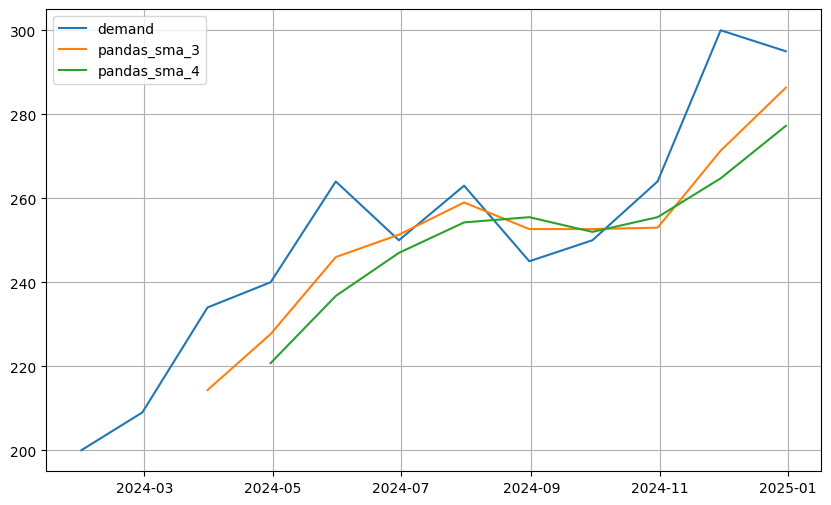

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(df['demand'],label='demand')
plt.plot(df['pandas_sma_3'],label='pandas_sma_3')
plt.plot(df['pandas_sma_4'],label='pandas_sma_4')
plt.legend(loc=2)

/tmp/ipykernel_699/2742681082.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['month'] = pd.date_range(start='2024-01-01', periods=12, freq='M')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Forecast for next 3 months
2025-01-31    275.127493
2025-02-28    275.127493
2025-03-31    275.127493
Freq: ME, dtype: float64


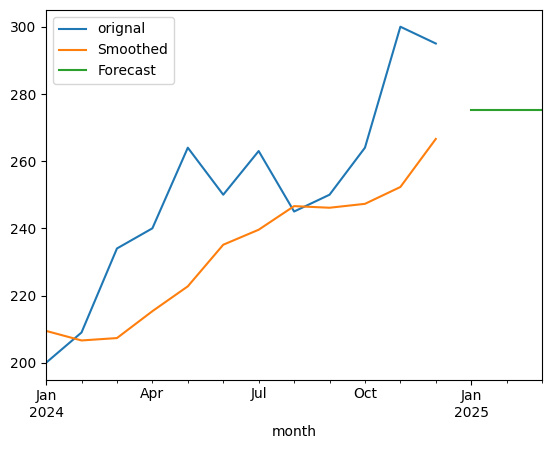

In [33]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
df['month'] = pd.date_range(start='2024-01-01', periods=12, freq='M')
df.set_index('month', inplace=True)
model = SimpleExpSmoothing(df['demand'], initialization_method='estimated').fit(smoothing_level=0.3, optimized=False)
df['SES'] = model.fittedvalues
forecast = model.forecast(3)
print("Forecast for next 3 months")
print(forecast)
df['demand'].plot(label='orignal')
df['SES'].plot(label='Smoothed')
forecast.plot(label='Forecast')
plt.legend()
plt.show()